<a href="https://colab.research.google.com/github/SumukhaSrivatsa-BSC/BSC_AI_Training/blob/main/10-07-2026/10_07_2026_Mini_Project_on_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 – Create the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Dataset
hours = np.arange(1, 21)

# Exam score ≈ Hours × 4.5 + noise
scores = hours * 4.5 + np.random.randint(-3, 4, size=len(hours))

df = pd.DataFrame({
    "Hours_Studied": hours,
    "Exam_Score": scores
})

print(df.head())
print("Shape:", df.shape)

   Hours_Studied  Exam_Score
0              1         7.5
1              2         9.0
2              3        14.5
3              4        21.0
4              5        21.5
Shape: (20, 2)


Task 2 – Initialize Weights and Biases

In [ ]:
# Convert to numpy arrays
X = df[["Hours_Studied"]].values.astype(float)
y = df[["Exam_Score"]].values.astype(float)

# Hidden layer
W1 = np.random.randn(1, 4) * 0.01
b1 = np.zeros((1, 4))

# Output layer
W2 = np.random.randn(4, 1) * 0.01
b2 = np.zeros((1, 1))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)


W1 shape: (1, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


Task 3 – Implement ReLU

In [ ]:
def relu(x):
    return np.maximum(0, x)

test = np.array([-3, -1, 0, 2, 5])

print("Original:", test)
print("ReLU:", relu(test))

Original: [-3 -1  0  2  5]
ReLU: [0 0 0 2 5]


Task 4 – Linear Output Activation

In [ ]:
def linear(x):
    return x

Task 5 – Forward Pass Function

In [ ]:
def forward(X, W1, b1, W2, b2):

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    y_pred = linear(Z2)

    cache = (Z1, A1, Z2)

    return y_pred, cache

In [ ]:
preds, cache = forward(X[:4], W1, b1, W2, b2)

print("Predictions:")
print(preds)

Predictions:
[[4.93499884e-07]
 [9.86999769e-07]
 [1.48049965e-06]
 [1.97399954e-06]]


Task 6 – Mean Squared Error Loss

In [ ]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

loss = mse_loss(y[:4], preds)

print("Loss:", loss)

Loss: 197.12496224726067


Task 7 – Backpropagation

In [ ]:
def backward(X, y_true, y_pred,
             W1, b1, W2, b2,
             cache):

    Z1, A1, Z2 = cache

    m = X.shape[0]

    # dLoss/dy_pred
    dZ2 = (2 / m) * (y_pred - y_true)

    # Output layer
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer
    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1.copy()
    dZ1[Z1 <= 0] = 0

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [ ]:
#Test gradients:
grads = backward(
    X[:4], y[:4], preds,
    W1, b1, W2, b2,
    cache
)

for k, v in grads.items():
    print(k, v.shape)

dW1 (1, 4)
db1 (1, 4)
dW2 (4, 1)
db2 (1, 1)


Task 8 – Optimizer Step

In [ ]:
def update_params(W1, b1, W2, b2,
                  grads, learning_rate):

    W1 -= learning_rate * grads["dW1"]
    b1 -= learning_rate * grads["db1"]

    W2 -= learning_rate * grads["dW2"]
    b2 -= learning_rate * grads["db2"]

    return W1, b1, W2, b2

In [ ]:
learning_rate = 0.001

Task 9 – Split Data Into Batches

In [ ]:
def create_batches(X, y, batch_size=4):

    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        batches.append((X_batch, y_batch))

    return batches

In [ ]:
batches = create_batches(X, y, batch_size=4)

print("Number of batches:", len(batches))

Number of batches: 5


Task 10 – Full Training Loop

In [ ]:
# Reinitialize parameters
np.random.seed(42)

W1 = np.random.randn(1, 4) * 0.01
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 1) * 0.01
b2 = np.zeros((1, 1))

learning_rate = 0.001
epochs = 100

loss_history = []

for epoch in range(epochs):

    batches = create_batches(X, y, batch_size=4)

    epoch_loss = 0

    for X_batch, y_batch in batches:

        # Forward
        y_pred, cache = forward(
            X_batch,
            W1, b1,
            W2, b2
        )

        # Loss
        loss = mse_loss(y_batch, y_pred)

        # Backprop
        grads = backward(
            X_batch,
            y_batch,
            y_pred,
            W1, b1,
            W2, b2,
            cache
        )

        # Update
        W1, b1, W2, b2 = update_params(
            W1, b1,
            W2, b2,
            grads,
            learning_rate
        )

        epoch_loss += loss

    avg_loss = epoch_loss / len(batches)

    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Epoch 1: Loss = 2897.4490
Epoch 10: Loss = 2569.6788
Epoch 20: Loss = 2220.6437
Epoch 30: Loss = 1934.9858
Epoch 40: Loss = 1701.2017
Epoch 50: Loss = 1509.8754
Epoch 60: Loss = 1353.2996
Epoch 70: Loss = 1225.1659
Epoch 80: Loss = 1120.3106
Epoch 90: Loss = 1034.5074
Epoch 100: Loss = 964.2970


Task 11 – Track Progress

In [ ]:
loss_history.append(avg_loss)

In [ ]:
print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Epoch 100: Loss = 964.2970


Task 12 – Plot Loss Curve

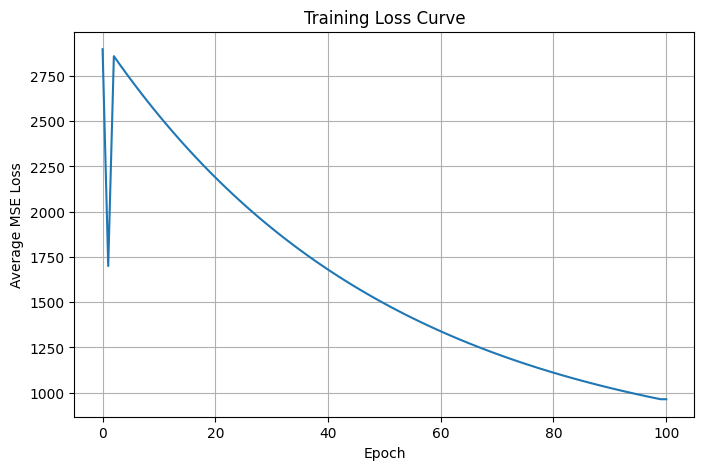

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")

plt.grid(True)
plt.show()

Task 13 – Test the Trained Model

In [ ]:
new_hours = np.array([[3],
                      [11],
                      [18]])

predictions, _ = forward(
    new_hours,
    W1, b1,
    W2, b2
)

for h, p in zip(new_hours, predictions):
    print(f"Hours Studied = {h[0]}, Predicted Score = {p[0]:.2f}")

Hours Studied = 3, Predicted Score = 30.10
Hours Studied = 11, Predicted Score = 30.10
Hours Studied = 18, Predicted Score = 30.10
